# Gold Price Prediction with Hybrid CNN-LSTM Model

This project aims to predict gold prices using a deep learning approach combining Convolutional Neural Networks (CNN) and Long Short-Term Memory (LSTM) networks. We will also compare the performance of this hybrid model with classical baseline models like Linear Regression and ARIMA.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Load and Inspect Data

In [5]:
# Load the dataset
df = pd.read_csv('../gold_price_forecasting_dataset.csv')

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
df.set_index('date', inplace=True)

# Display basic info
print("Shape of dataset:", df.shape)
display(df.head())
display(df.info())
display(df.describe())

Shape of dataset: (1167, 17)


,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
date,,,,,,,,,,,,,,,,,
2021-06-11,1877.400024,1877.400024,1902.300049,1875.199951,1900.900024,349,1887.828561,1860.180005,1790.618891,-0.008869,0.009353,0.007538,54.722931,19.724030,24.933953,1918.242879,1853.797124
2021-06-14,1864.000000,1864.000000,1866.599976,1846.500000,1866.199951,41,1886.799997,1863.403337,1790.972225,-0.007138,0.006411,0.007711,49.391919,16.433420,23.233846,1913.119794,1861.530206
2021-06-15,1854.500000,1854.500000,1867.199951,1854.400024,1866.400024,78,1881.757132,1865.506669,1791.701114,-0.005097,0.004572,0.007474,45.972581,12.910196,21.169116,1914.969370,1858.380630
2021-06-16,1859.500000,1859.500000,1860.099976,1809.199951,1859.400024,117,1876.428554,1868.296667,1792.241113,0.002696,0.004348,0.007240,48.012515,10.401571,19.015607,1915.862799,1856.657196
2021-06-17,1773.800049,1773.800049,1823.300049,1769.599976,1811.800049,1135,1859.514282,1867.953337,1791.595558,-0.046088,0.016895,0.011288,28.293542,1.481124,15.508710,1938.202457,1823.567538


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1167 entries, 2021-06-11 to 2026-01-30
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   adj close      1167 non-null   float64
 1   close          1167 non-null   float64
 2   high           1167 non-null   float64
 3   low            1167 non-null   float64
 4   open           1167 non-null   float64
 5   volume         1167 non-null   int64  
 6   ma_7           1167 non-null   float64
 7   ma_30          1167 non-null   float64
 8   ma_90          1167 non-null   float64
 9   daily_return   1167 non-null   float64
 10  volatility_7   1167 non-null   float64
 11  volatility_30  1167 non-null   float64
 12  rsi            1167 non-null   float64
 13  macd           1167 non-null   float64
 14  macd_signal    1167 non-null   float64
 15  bb_upper       1167 non-null   float64
 16  bb_lower       1167 non-null   float64
dtypes: float64(16), int64(1)
memory us

None

,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
count,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000
mean,2363.105823,2363.105823,2375.595715,2349.989545,2362.322109,4170.995716,2354.938862,2327.283295,2263.573357,0.000840,0.009373,0.009724,54.598187,16.332400,15.839374,2420.275644,2257.229746
std,749.127289,749.127289,757.244374,741.042344,749.389242,21394.527815,735.998718,697.354115,620.008940,0.010809,0.004356,0.002901,12.176024,31.412668,28.476902,758.759131,668.408638
min,1623.300049,1623.300049,1623.300049,1615.099976,1620.400024,0.000000,1643.671422,1659.240002,1705.499999,-0.113662,0.001791,0.004386,22.230260,-35.037415,-31.681349,1681.970545,1579.241564
25%,1827.299988,1827.299988,1831.600037,1816.800049,1825.250000,88.000000,1827.585711,1830.560004,1813.691667,-0.004360,0.006640,0.008116,46.452632,-4.904126,-4.022000,1881.291203,1775.139339
50%,1985.900024,1985.900024,1996.199951,1979.800049,1989.000000,297.000000,1986.785697,1978.813334,1948.046665,0.000945,0.008522,0.009115,53.983908,9.242215,9.448693,2038.438645,1932.450329
75%,2666.099976,2666.099976,2675.449951,2654.599976,2662.400024,867.500000,2654.771449,2659.524996,2588.156108,0.006842,0.011139,0.010711,62.790872,29.596166,28.529324,2728.408233,2582.183753
max,5318.399902,5318.399902,5586.200195,5301.600098,5415.700195,209783.000000,5070.914272,4620.783317,4252.532210,0.043643,0.051106,0.027369,87.227702,227.374043,170.076845,5310.168254,4263.597132


## 2. Exploratory Data Analysis (EDA)

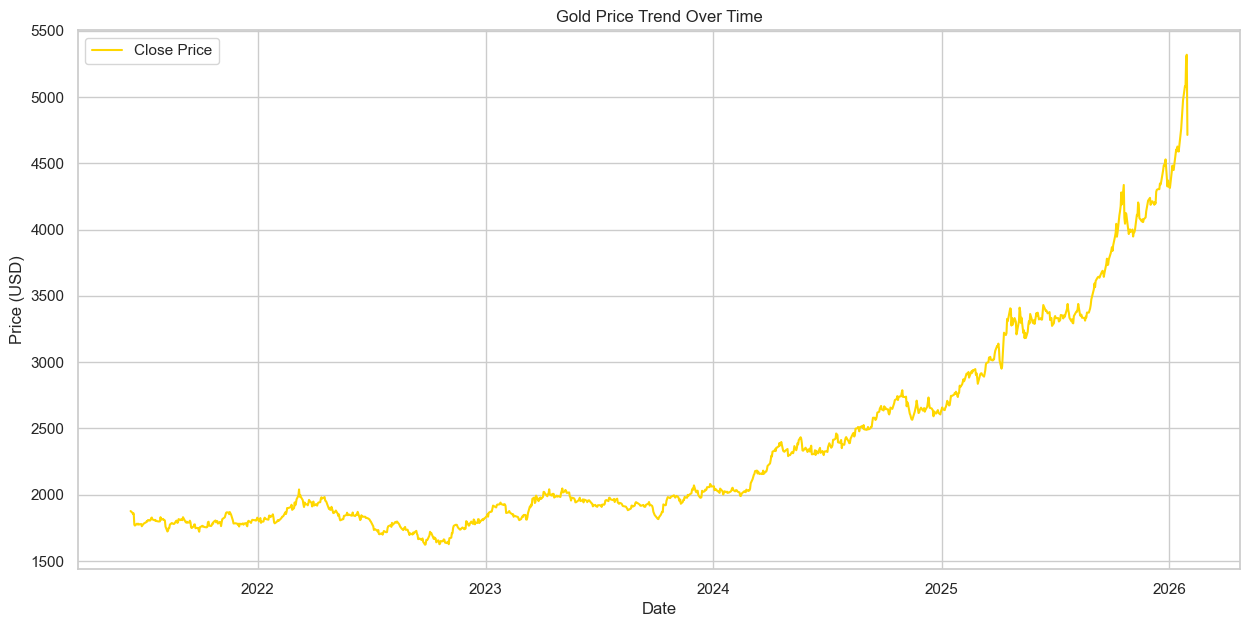

In [18]:
# Plot Gold Price Trend
plt.figure(figsize=(15, 7))
plt.plot(df['close'], label='Close Price', color='gold')
plt.title('Gold Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

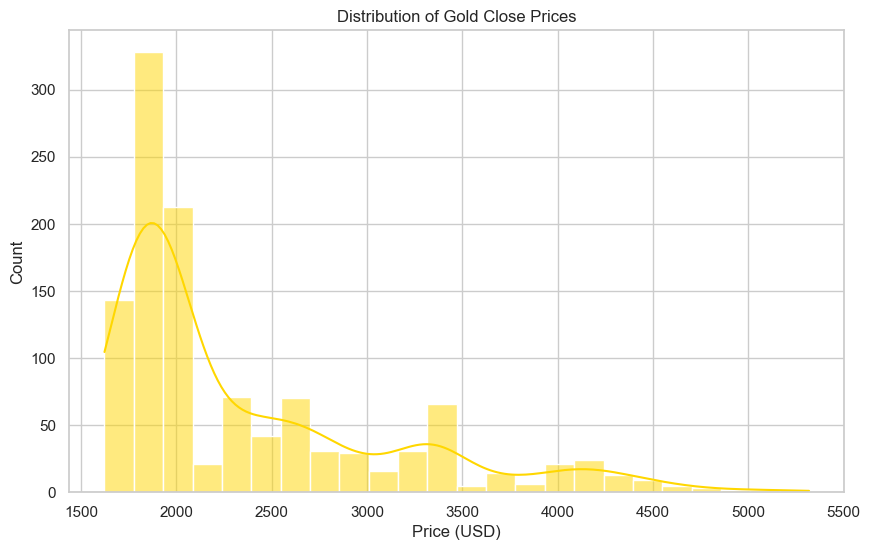

In [5]:
# Distribution of Close Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['close'], kde=True, color='gold')
plt.title('Distribution of Gold Close Prices')
plt.xlabel('Price (USD)')
plt.show()

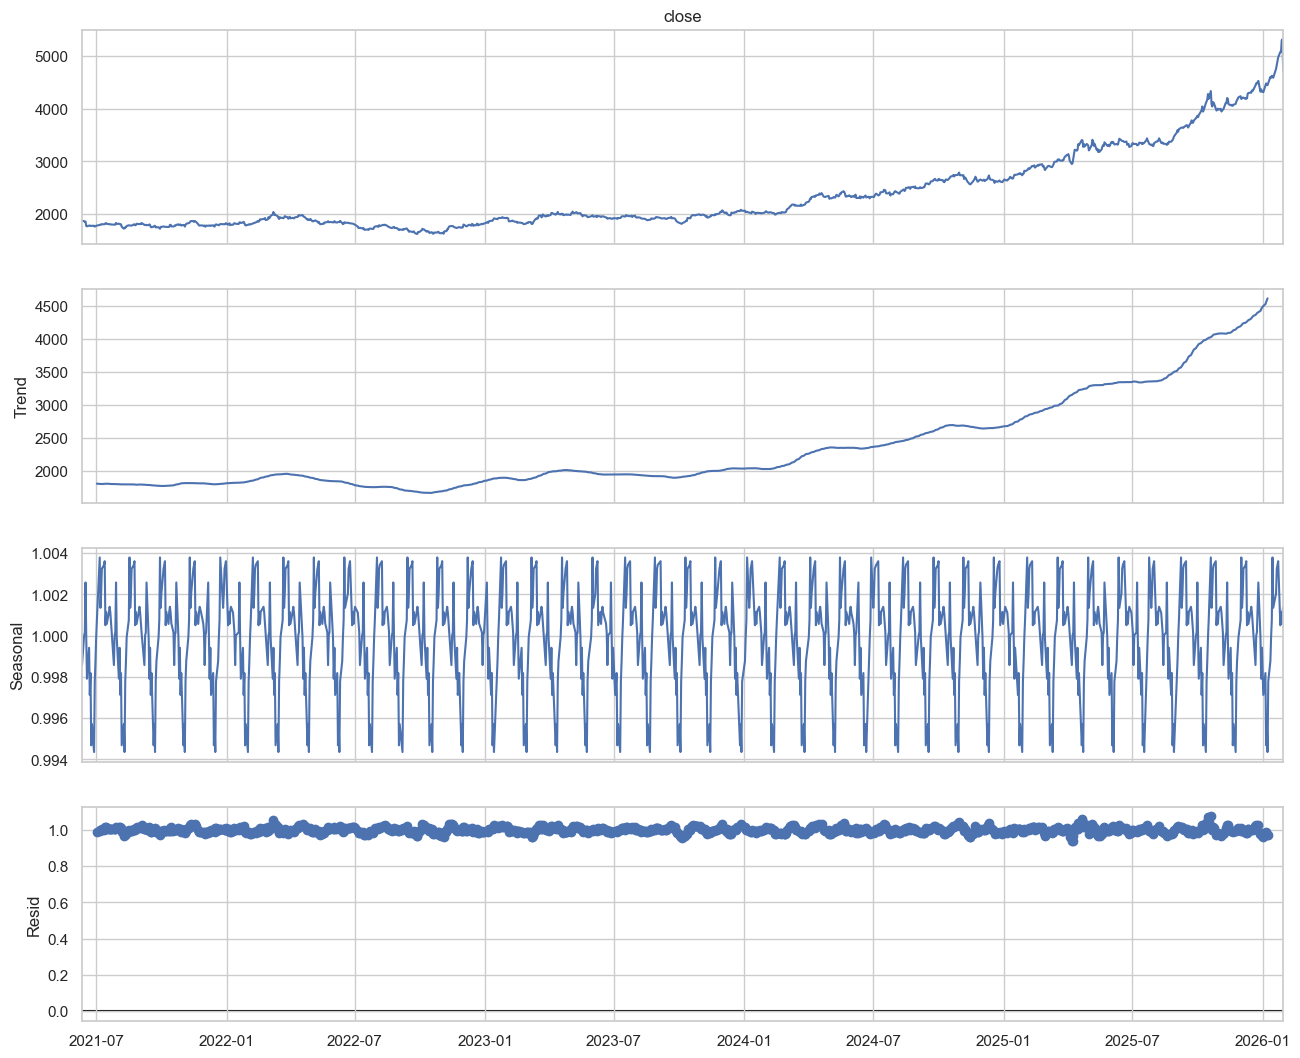

In [6]:
# Seasonal Decomposition
result = seasonal_decompose(df['close'], model='multiplicative', period=30)
fig = result.plot()
fig.set_size_inches(15, 12)
plt.show()

## 3. Data Preprocessing

In [7]:
# Filter features and target (using 'close' as target)
features = ['close', 'ma_7', 'ma_30', 'ma_90', 'rsi', 'macd', 'macd_signal', 'bb_upper', 'bb_lower']
data = df[features].values

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)

Scaled data shape: (1167, 9)


In [8]:
# Function to create windowed dataset for CNN-LSTM
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size, 0]) # Targeting 'close' price
    return np.array(X), np.array(y)

WINDOW_SIZE = 30
X, y = create_windows(scaled_data, WINDOW_SIZE)

# Split into train and test (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (909, 30, 9), y_train: (909,)
X_test: (228, 30, 9), y_test: (228,)


## 4. Baseline Models

### 4.1 Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Flatten windows for linear regression
X_train_lr = X_train.reshape(X_train.shape[0], -1)
X_test_lr = X_test.reshape(X_test.shape[0], -1)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)
lr_preds = lr_model.predict(X_test_lr)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print(f"Linear Regression - MAE: {lr_mae:.4f}, RMSE: {lr_rmse:.4f}")

Linear Regression - MAE: 0.0131, RMSE: 0.0194


### 4.2 ARIMA

In [10]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA works on univariate data, using 'close' price directly (scaled)
train_close = scaled_data[:split + WINDOW_SIZE, 0]
test_close = scaled_data[split + WINDOW_SIZE:, 0]

arima_model = ARIMA(train_close, order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_preds = arima_fit.forecast(steps=len(test_close))

arima_mae = mean_absolute_error(test_close, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test_close, arima_preds))

print(f"ARIMA - MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}")

ARIMA - MAE: 0.2052, RMSE: 0.2493


## 5. Hybrid CNN-LSTM Model

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten

model = Sequential([
    # CNN layers to capture spatial features/patterns
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    # LSTM layers to capture temporal dependencies
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dropout(0.2),
    
    # Dense layers for final prediction
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 50)         │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,293 (180.83 KB)

 Trainable params: 46,293 (180.83 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Training the model
history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0065 - val_loss: 3.9603e-04
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1796e-04 - val_loss: 6.0745e-04
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4440e-04 - val_loss: 4.3873e-04
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3362e-04 - val_loss: 4.1188e-04
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9269e-04 - val_loss: 5.6405e-04
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0375e-04 - val_loss: 3.0836e-04
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8570e-04 - val_loss: 2.9431e-04
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7782e-04 - val_loss: 2.9985e-04
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7123e-04 - val_loss: 3.1167e-04
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3957e-04 - val_loss: 2.7617e-04
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5502e-04 - val_loss: 

In [13]:
# Evaluation
cnn_lstm_preds = model.predict(X_test)
cnn_lstm_mae = mean_absolute_error(y_test, cnn_lstm_preds)
cnn_lstm_rmse = np.sqrt(mean_squared_error(y_test, cnn_lstm_preds))

print(f"Hybrid CNN-LSTM - MAE: {cnn_lstm_mae:.4f}, RMSE: {cnn_lstm_rmse:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Hybrid CNN-LSTM - MAE: 0.0944, RMSE: 0.1161


## 6. Performance Comparison

,Model,MAE,RMSE
0,Linear Regression,0.013057,0.019355
1,ARIMA,0.205245,0.249296
2,Hybrid CNN-LSTM,0.094396,0.116077


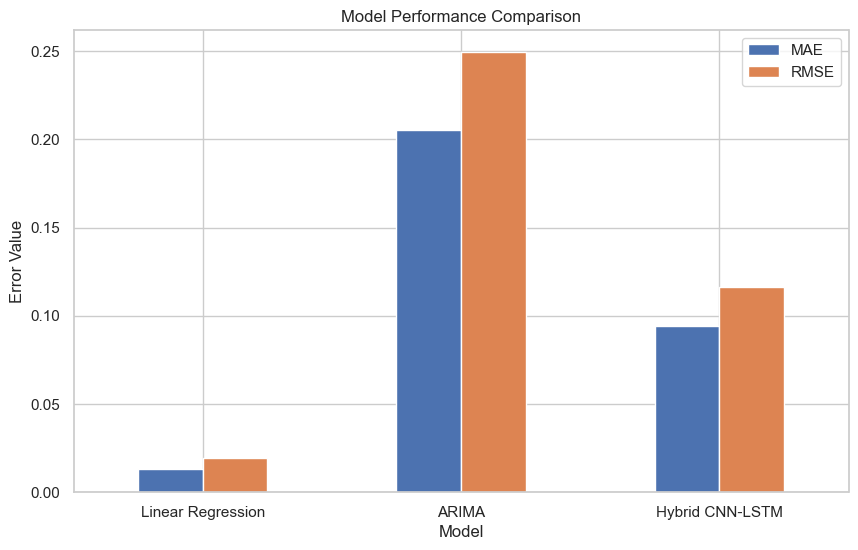

In [14]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'ARIMA', 'Hybrid CNN-LSTM'],
    'MAE': [lr_mae, arima_mae, cnn_lstm_mae],
    'RMSE': [lr_rmse, arima_rmse, cnn_lstm_rmse]
})

display(results)

# Plot comparison
results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Error Value')
plt.xticks(rotation=0)
plt.show()

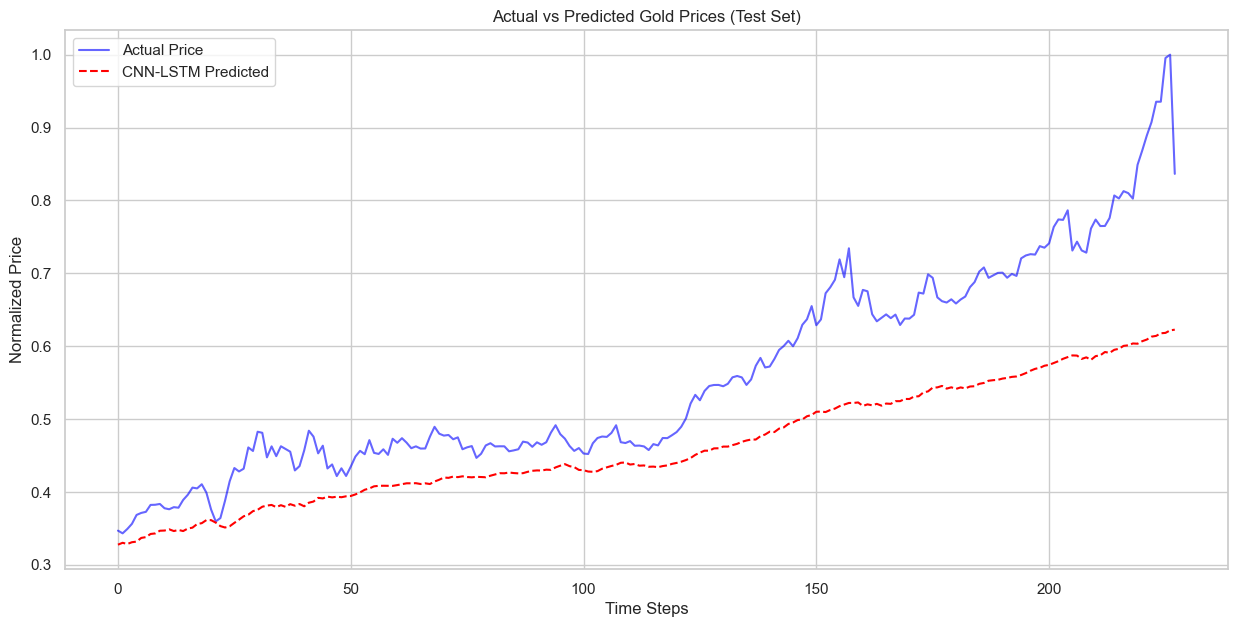

In [15]:
# Visualize Predictions vs Actual
plt.figure(figsize=(15, 7))
plt.plot(y_test, label='Actual Price', color='blue', alpha=0.6)
plt.plot(cnn_lstm_preds, label='CNN-LSTM Predicted', color='red', linestyle='--')
plt.title('Actual vs Predicted Gold Prices (Test Set)')
plt.xlabel('Time Steps')
plt.ylabel('Normalized Price')
plt.legend()
plt.show()

Detailed Analysis: Gold Price Prediction Notebook
This document provides a cell-by-cell breakdown of the gold_price_prediction.ipynb notebook, explaining the methodology, logic, and significance of each step in the research process.

1. Setup and Library Imports
Code Cell 1

Purpose: Initialize the environment with necessary data science and machine learning libraries.
Key Libraries:
pandas & numpy: Data manipulation and numerical operations.
matplotlib & seaborn: Data visualization with customized themes.
statsmodels: Time-series analysis (decomposition and ARIMA).
sklearn: Data scaling and classical machine learning.
tensorflow: Deep learning infrastructure for the CNN-LSTM hybrid.
2. Data Loading and Inspection
Code Cell 2

Logic:
Read the gold_price_forecasting_dataset.csv.
Convert the date column to a datetime object to enable time-aware indexing.
Set the date as the index to simplify time-series slicing and plotting.
Significance: Ensuring the data is sorted chronologically is critical for time-series models to prevent "look-ahead" bias.
3. Exploratory Data Analysis (EDA)
Code Cells 3, 4, and 5

Cell 3 (Trend Plot): Visualizes the raw closing price over the entire period. This helps identify the general trend (bullish/bearish) and any extreme volatility spikes.
Cell 4 (Price Distribution): Uses a Histogram and Kernel Density Estimate (KDE). Gold prices are often skewed; understanding this helps determine if standard scaling or other transformations are needed.
Cell 5 (Seasonal Decomposition): Breaks the time-series into three components: Trend, Seasonality, and Residuals (noise) using a multiplicative model. This confirms whether the price changes are due to a long-term trend or recurring seasonal cycles.
4. Data Preprocessing
Code Cells 6 and 7

Cell 6 (Scaling):
Filters relevant features (Close, Moving Averages, RSI, MACD, Bollinger Bands).
Applies MinMaxScaler (0, 1). Deep learning models (especially LSTMs) are sensitive to input magnitudes; normalization ensures faster convergence.
Cell 7 (Time-Series Windowing):
Logic: Creates overlapping sequences of 30 days (the "window") to predict the 31st day.
Data Split: Performs an 80/20 train-test split. Crucially, this split is chronological (not shuffled) to maintain the time order.
5. Classical Baseline Models
Code Cells 8 and 9

Linear Regression (Cell 8): Uses the flattened 30-day window as independent features. This serves as a "naive" statistical benchmark.
ARIMA (Cell 9): Implements an Autoregressive Integrated Moving Average model. This is the industry standard for univariate time-series. It acts as the "mid-tier" benchmark.
6. Hybrid CNN-LSTM Model
Code Cells 10, 11, and 12

Architecture (Cell 10):
Conv1D: Detects local patterns or "motifs" across multiple technical indicators.
MaxPooling: Reduces dimensionality while preserving the strongest feature signals.
LSTM layers: Processes the spatial features extracted by the CNN over time to remember long-term dependencies.
Dropout: Introduced to prevent the complex model from overfitting the training data.
Training (Cell 11): Trains for 50 epochs with a validation split.
Evaluation (Cell 12): Calculates MAE and RMSE on the test set.
7. Results and Visualization
Code Cells 13 and 14

Comparison (Cell 13): Aggregates errors into a tabular and bar chart format. This allows for an objective "head-to-head" comparison.
Final Forecast Plot (Cell 14): Overlays the actual test set prices with the CNN-LSTM predictions. The goal is to see how closely the red dashed line (prediction) tracks the blue line (actual), especially at critical turning points.